In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import random
import matplotlib.pyplot as plt
from collections import Counter
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import StratifiedShuffleSplit
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report


In [ ]:
class EEGDataset(Dataset):
    def __init__(self, data_dir, crop_length=750):
        self.data_dir = data_dir
        self.crop_length = crop_length
        self.file_list = [f for f in os.listdir(data_dir) if f.endswith('.csv')]
        random.shuffle(self.file_list)

        self.file_list = self.file_list[:300]  # ✅ small set for debug/dev

        self.data_list = []
        self.label_list = []
        for file in self.file_list:
            label = int(file.split('_')[0])
            try:
                data = pd.read_csv(os.path.join(data_dir, file)).iloc[:, :19].values.T
                self.data_list.append(data)
                self.label_list.append(label)
            except Exception as e:
                print(f"Skipping {file} due to error: {e}")

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        label = self.label_list[idx]
        data = self.data_list[idx]

        if data.shape[1] > self.crop_length:
            start = np.random.randint(0, data.shape[1] - self.crop_length)
            data = data[:, start:start + self.crop_length]
        else:
            pad = self.crop_length - data.shape[1]
            data = np.pad(data, ((0, 0), (0, pad)), mode='constant')

        data = (data - data.mean(axis=1, keepdims=True)) / (data.std(axis=1, keepdims=True) + 1e-8)
        return torch.tensor(data, dtype=torch.float32), label


In [ ]:
from collections import defaultdict

data_dir = "/content/drive/MyDrive/Internship1/3LABELDDS/caueeg-dataset(all)/signals_csv"  # CHANGE THIS
dataset = EEGDataset(data_dir=data_dir, crop_length=750)

all_labels = dataset.label_list
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(sss.split(np.zeros(len(all_labels)), all_labels))

train_data_by_class = defaultdict(list)
val_ds = Subset(dataset, val_idx)

# Group training samples by class
for i in train_idx:
    data, label = dataset[i]
    train_data_by_class[label].append((data, label))

# Find maximum count (target for oversampling)
max_count = max(len(samples) for samples in train_data_by_class.values())

# Oversample each class to match the max count
train_data_balanced = []
train_labels_balanced = []

for label, samples in train_data_by_class.items():
    current = len(samples)
    needed = max_count - current
    full_samples = samples.copy()

    # If underrepresented, randomly duplicate until balanced
    if needed > 0:
        duplicates = random.choices(samples, k=needed)
        full_samples.extend(duplicates)

    for data, label in full_samples:
        train_data_balanced.append(data)
        train_labels_balanced.append(label)

# Wrap into a Dataset
class OversampledDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

train_ds_balanced = OversampledDataset(train_data_balanced, train_labels_balanced)

# Fast CPU-friendly DataLoader
train_loader = DataLoader(train_ds_balanced, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=2)

# Confirm final distribution
print("✅ Oversampled Train:", len(train_ds_balanced), "| Val:", len(val_ds))
print("✅ New Train dist:", dict(Counter(train_labels_balanced)))


✅ Oversampled Train: 315 | Val: 60
✅ New Train dist: {1: 105, 0: 105, 2: 105}


In [ ]:
class ShallowEEG(nn.Module):
    def __init__(self, in_channels=19, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.net(x)


In [ ]:
  xdevice = torch.device("cpu")

model = ShallowEEG().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

epochs = 20
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(1, epochs + 1):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (out.argmax(dim=1) == y).sum().item()
        total += y.size(0)

    train_acc = correct / total
    train_losses.append(total_loss / len(train_loader))
    train_accuracies.append(train_acc)

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            val_loss += criterion(out, y).item()
            preds = out.argmax(dim=1)
            y_true += y.cpu().tolist()
            y_pred += preds.cpu().tolist()
            val_correct += (preds == y).sum().item()
            val_total += y.size(0)

    val_acc = val_correct / val_total
    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch:02d} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val Loss: {val_loss:.4f}")


Epoch 01 | Train Acc: 0.3468 | Val Acc: 0.3000 | Val Loss: 4.3828
Epoch 02 | Train Acc: 0.3434 | Val Acc: 0.3833 | Val Loss: 4.3664
Epoch 03 | Train Acc: 0.3569 | Val Acc: 0.4000 | Val Loss: 4.3561
Epoch 04 | Train Acc: 0.3670 | Val Acc: 0.3833 | Val Loss: 4.3762
Epoch 05 | Train Acc: 0.3771 | Val Acc: 0.3833 | Val Loss: 4.3466
Epoch 06 | Train Acc: 0.3805 | Val Acc: 0.3000 | Val Loss: 4.3808
Epoch 07 | Train Acc: 0.3973 | Val Acc: 0.4167 | Val Loss: 4.3641
Epoch 08 | Train Acc: 0.4074 | Val Acc: 0.3500 | Val Loss: 4.3593
Epoch 09 | Train Acc: 0.4108 | Val Acc: 0.4000 | Val Loss: 4.3682
Epoch 10 | Train Acc: 0.4175 | Val Acc: 0.4667 | Val Loss: 4.3490
Epoch 11 | Train Acc: 0.4242 | Val Acc: 0.3333 | Val Loss: 4.3857
Epoch 12 | Train Acc: 0.4209 | Val Acc: 0.3667 | Val Loss: 4.3798
Epoch 13 | Train Acc: 0.4276 | Val Acc: 0.4500 | Val Loss: 4.3646
Epoch 14 | Train Acc: 0.4411 | Val Acc: 0.4333 | Val Loss: 4.3513
Epoch 15 | Train Acc: 0.4411 | Val Acc: 0.4000 | Val Loss: 4.4005
Epoch 16 |

NameError: name 'train_losses' is not defined

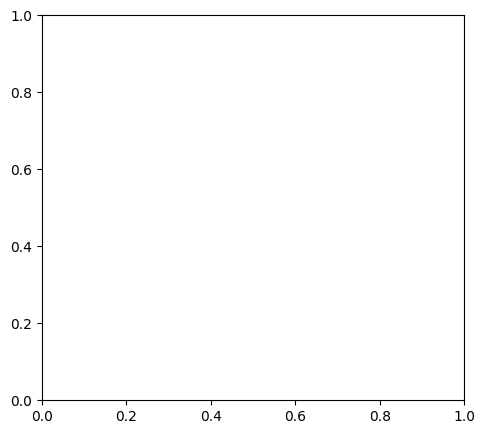

In [ ]:
#Cell 6
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Plot loss and accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title("Loss over Epochs")

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Accuracy over Epochs")

plt.tight_layout()
plt.show()

# Classification Report
print("\n📋 Final Classification Report:")
print(classification_report(all_y_true, all_y_pred, target_names=["Normal", "MCI", "AD"], digits=4))

# Confusion Matrix
cm = confusion_matrix(all_y_true, all_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=["Normal", "MCI", "AD"],
            yticklabels=["Normal", "MCI", "AD"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


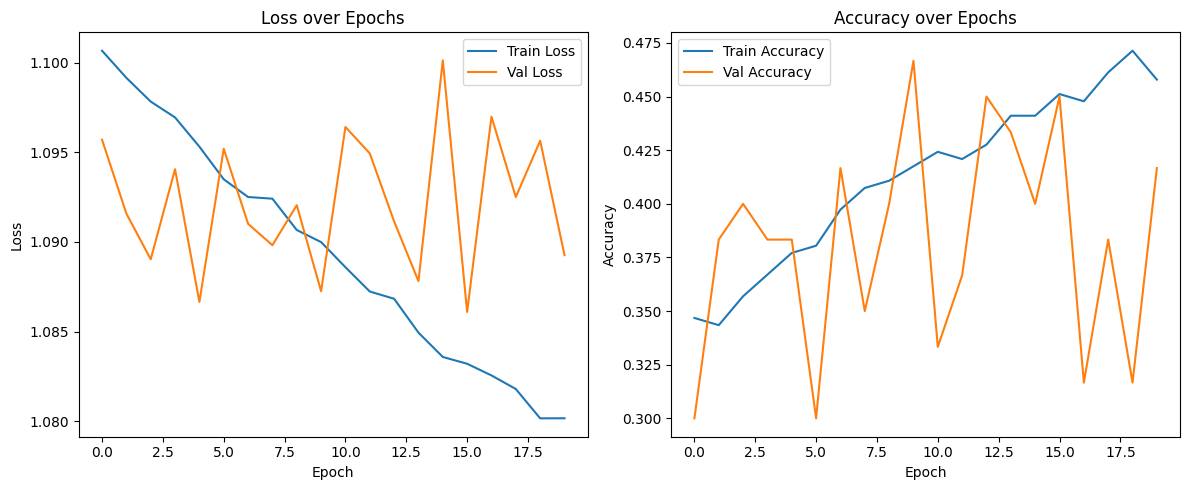


Final Classification Report:
              precision    recall  f1-score   support

      Normal     0.3913    0.3600    0.3750        25
         MCI     0.3871    0.5455    0.4528        22
          AD     0.6667    0.3077    0.4211        13

    accuracy                         0.4167        60
   macro avg     0.4817    0.4044    0.4163        60
weighted avg     0.4494    0.4167    0.4135        60



In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title("Loss over Epochs")

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Accuracy over Epochs")

plt.tight_layout()
plt.show()

print("\nFinal Classification Report:")
print(classification_report(y_true, y_pred, target_names=["Normal", "MCI", "AD"], digits=4))
